# TV sweeps (manual layout): Burgers (noise=0.7, stride_x=5)

Runs multiple training loops (8k steps each) under the baseline dataset settings and varying `lambda_tv`.

For each run it prints:
- `symnet.effective_quadratic_matrix()`
- `symnet.readout.weight`

And generates:
- `hlprs.snapshot_comp(..., snap_no=10)`
- loss curves for data / PDE / TV


In [1]:
import sys

sys.path.append('..')  # add project root

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from prog import mlps, featlib, trainer, hlprs
import Datasets.matconv as mc

SEED = 1432
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device('cpu')


In [13]:
# Baseline dataset settings (matches noise_test.ipynb cell 46)

noise = 0.7
nu = 0.02
stride_t = 1
stride_x = 5
part_num = 1
which_part = 1
seed = SEED

# Training settings
selected_derivs = ('u','u_x','u_xx')

lr = 1e-3
batch_size = 1000
steps = 4000
log_every = 1000

lam_pde = 0.5
lam_reg = 0.0
lam_data = 10.0

# TV sweep
lambda_tv_values = [1e-2, 0.1, 0.5, 1, 10.0]

# Fixed u-model architecture (change if desired)
U_N_LAYERS = 4
U_HIDDEN = 64
U_ACT = mlps.Sin


In [14]:
# Dataset building

partitions = mc.build_dataset_from_burgers(
    noise_level=noise,
    nu=nu,
    stride_t=stride_t,
    stride_x=stride_x,
    seed=seed,
    quantile_splits=part_num,
    return_partitions=True,
)

key = [k for k in partitions if k.startswith(f'Q{which_part}:')][0]
t_np, x_np, y_np, y_noisy_np, N = partitions[key]

# batches are generated over t_np, x_np, y_np, y_noisy_np

t_torch       = torch.from_numpy(t_np).to(device)
x_torch       = torch.from_numpy(x_np).to(device)
y_clean_torch = torch.from_numpy(y_np).to(device)
y_noisy_torch = torch.from_numpy(y_noisy_np).to(device)

print('N points:', t_np.shape[0])
print('x_unique:', len(np.unique(x_np)), 't_unique:', len(np.unique(t_np)))


N points: 13104
x_unique: 52 t_unique: 252


In [15]:
# TV penalty (smoothed TV in space)

def tv1d_space(u_fn, t, x, eps=1e-6):
    # E[ sqrt( (du/dx)^2 + eps^2 ) ]
    u = u_fn(t, x)
    ones = torch.ones_like(u)
    ux = torch.autograd.grad(
        u, x,
        grad_outputs=ones,
        create_graph=True,
        retain_graph=True,
    )[0]
    return torch.sqrt(ux**2 + eps**2).mean()


In [16]:
def run_one(lambda_tv: float):
    # Repro per-run
    np.random.seed(SEED)
    torch.manual_seed(SEED)

    # Initializing u_model and symnet
    u_model = mlps.SimpleMLP(n_layers=U_N_LAYERS, hidden_size=U_HIDDEN, act=U_ACT)
    symnet = mlps.EQL(in_dim=len(selected_derivs), prod_dim=2, bias=False)

    train_config = trainer.TrainerConfig(
        lr=lr,
        lambda_pde=lam_pde,
        lambda_reg=lam_reg,
        lambda_tv=lambda_tv,
        lambda_data=lam_data,
        selected_derivs=selected_derivs,
        device=device,
    )

    ft = featlib.FeatureTensor(selected_derivs, normalize=False)
    feature_builder = ft.build

    train = trainer.PDETrainer(
        u_model=u_model,
        v_model=symnet,
        cfg=train_config,
        feature_builder=feature_builder,
    )

    loss_dat = []
    loss_ps = []
    loss_tv = []

    for i in range(steps):
        t, x, u_noisy, u_clean = hlprs.make_batch(
            batch_size=batch_size,
            t_torch=t_torch,
            x_torch=x_torch,
            y_clean=y_clean_torch,
            y_noisy=y_noisy_torch,
        )

        out = train.step(t=t, x=x, u_noisy=u_noisy, u_clean=u_clean, tv_fn=tv1d_space)
        loss_dat.append(out['loss_data'])
        loss_ps.append(out['loss_pde'])
        loss_tv.append(out['loss_tv'])

        if log_every and i % log_every == 0:
            print(f'[lam_tv={lambda_tv:g}] step {i} data={out["loss_data"]:.6e} pde={out["loss_pde"]:.6e} tv={out["loss_tv"]:.6e}')

    # Print coefficients
    print('[lam_tv=', lambda_tv, '] effective quadratic matrix (symnet):')
    print(symnet.effective_quadratic_matrix(symmetrize=True))
    print('[lam_tv=', lambda_tv, '] readout.weight:')
    print(symnet.readout.weight)

    # Snapshot comparison
    hlprs.snapshot_comp(train.u, stride_x, stride_t, y_noisy_np, y_np, t_np, x_np, snap_no=10)[:0]

    # Loss plots
    plt.figure(figsize=(7,4))
    plt.plot(loss_dat, label='data')
    plt.plot(loss_ps, label='pde')
    plt.plot(loss_tv, label='tv')
    plt.yscale('log')
    plt.xlabel('step')
    plt.ylabel('loss')
    plt.title(f'Loss curves (lam_tv={lambda_tv:g})')
    plt.legend()
    plt.tight_layout()
    plt.show()

    return {
        'lambda_tv': lambda_tv,
        'loss_data': loss_dat,
        'loss_pde': loss_ps,
        'loss_tv': loss_tv,
        'train': train,
    }


Running lambda_tv = 0.01
[lam_tv=0.01] step 0 data=9.140940e-01 pde=7.762921e-03 tv=1.267108e-02


[lam_tv=0.01] step 1000 data=4.633198e-01 pde=7.544837e-03 tv=6.102136e-01
[lam_tv=0.01] step 2000 data=4.901863e-01 pde=1.252893e-02 tv=6.051587e-01
[lam_tv=0.01] step 3000 data=5.242245e-01 pde=5.922634e-03 tv=6.626107e-01
[lam_tv= 0.01 ] effective quadratic matrix (symnet):
tensor([[-0.0766, -0.5124, -0.0132],
        [-0.5124,  0.0175, -0.0153],
        [-0.0132, -0.0153, -0.0007]])
[lam_tv= 0.01 ] readout.weight:
Parameter containing:
tensor([[-0.0323, -0.0039, -0.0055,  0.5919]], requires_grad=True)
max_abs_diff = 0.140087


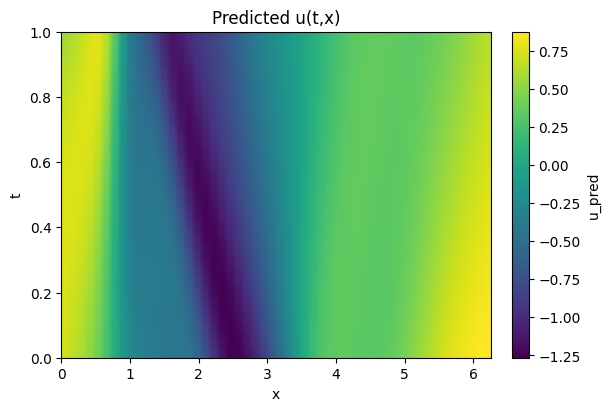

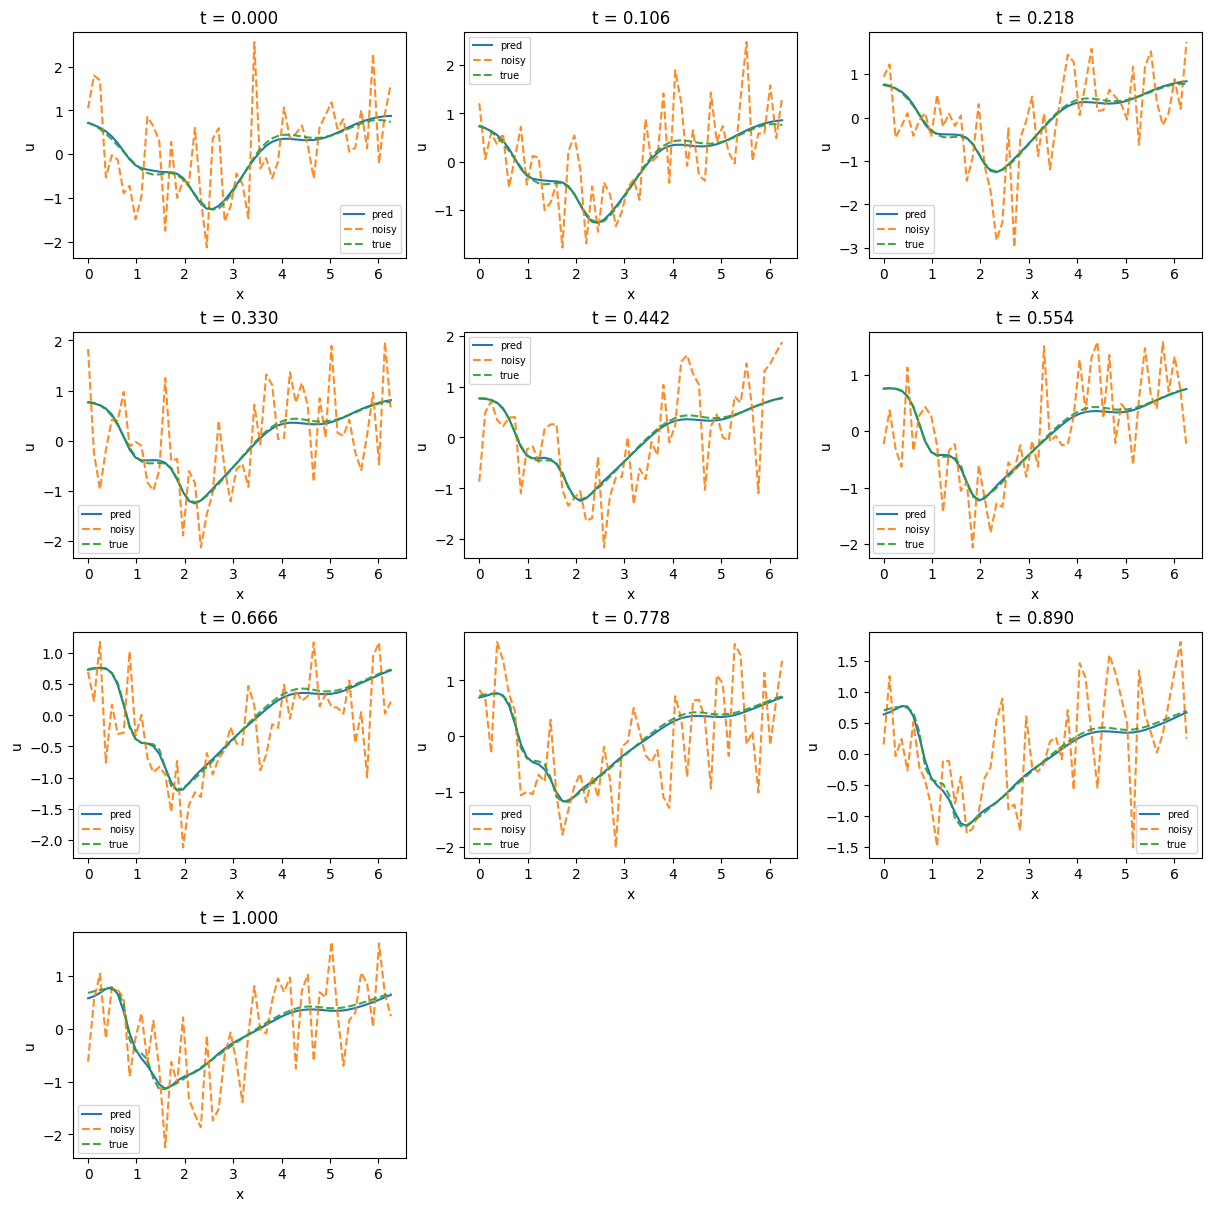

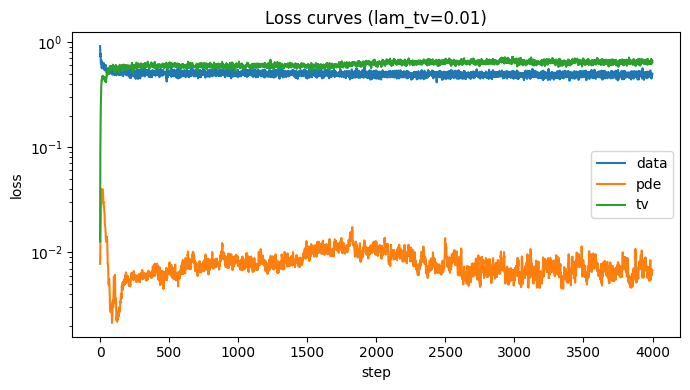

Running lambda_tv = 0.1
[lam_tv=0.1] step 0 data=9.140940e-01 pde=7.762921e-03 tv=1.267108e-02
[lam_tv=0.1] step 1000 data=4.631842e-01 pde=7.338801e-03 tv=5.980850e-01
[lam_tv=0.1] step 2000 data=4.910319e-01 pde=1.367503e-02 tv=5.865318e-01
[lam_tv=0.1] step 3000 data=5.236420e-01 pde=6.309612e-03 tv=6.305547e-01
[lam_tv= 0.1 ] effective quadratic matrix (symnet):
tensor([[-0.1019, -0.5168, -0.0174],
        [-0.5168,  0.0204, -0.0163],
        [-0.0174, -0.0163, -0.0010]])
[lam_tv= 0.1 ] readout.weight:
Parameter containing:
tensor([[-0.0433,  0.0010, -0.0048,  0.5919]], requires_grad=True)
max_abs_diff = 0.165271


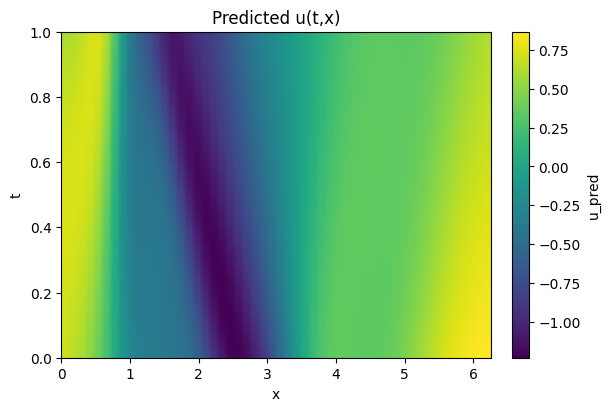

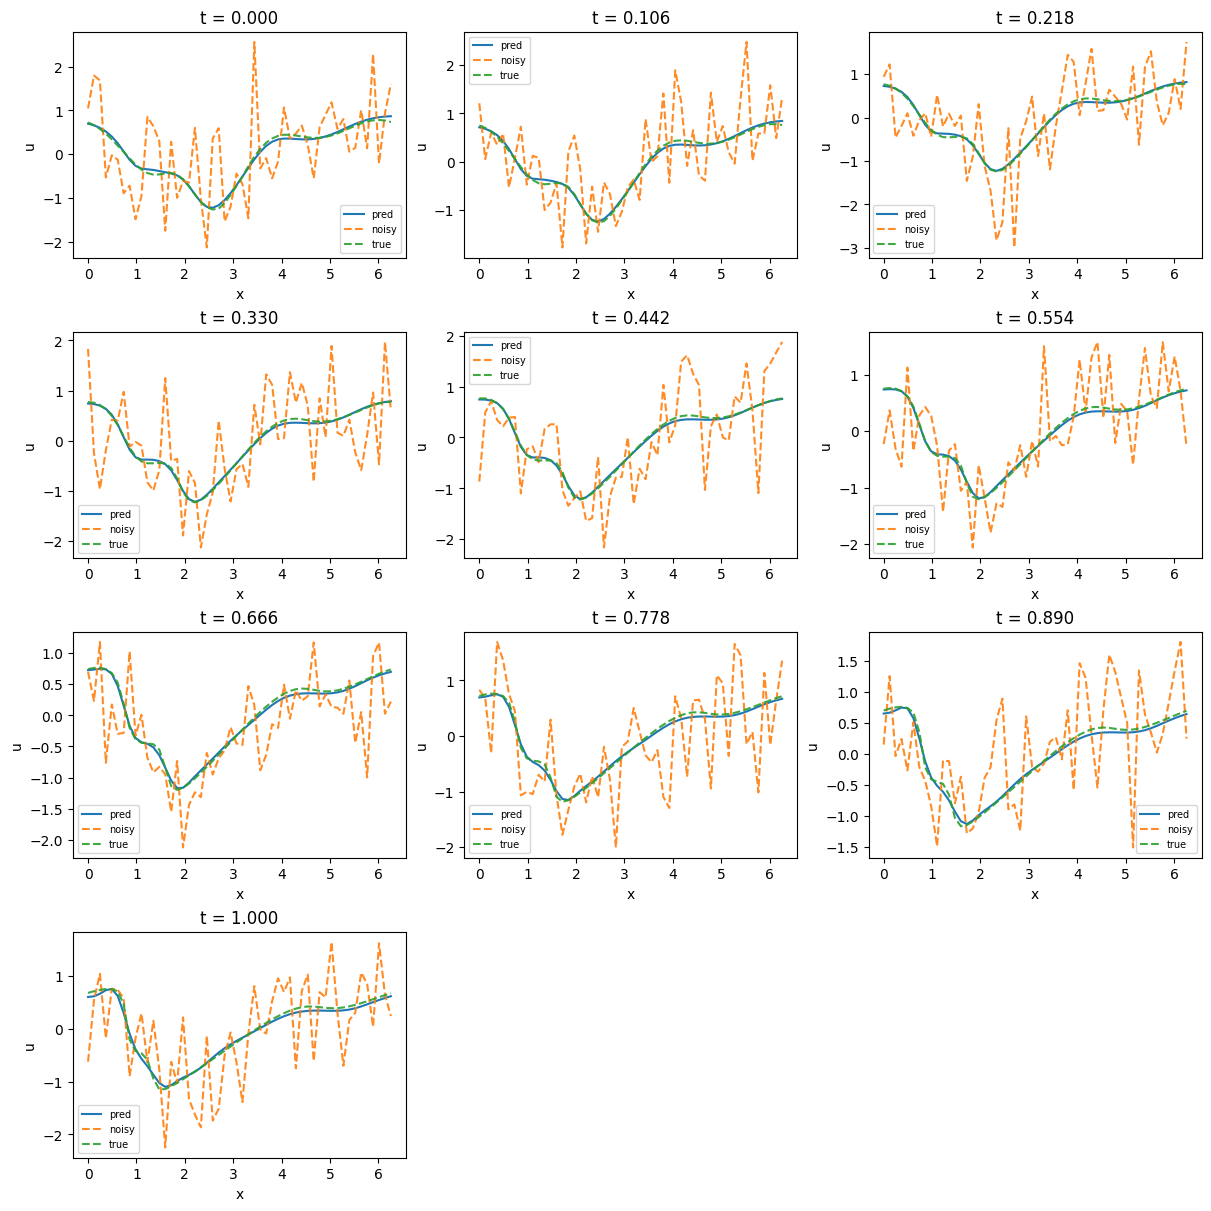

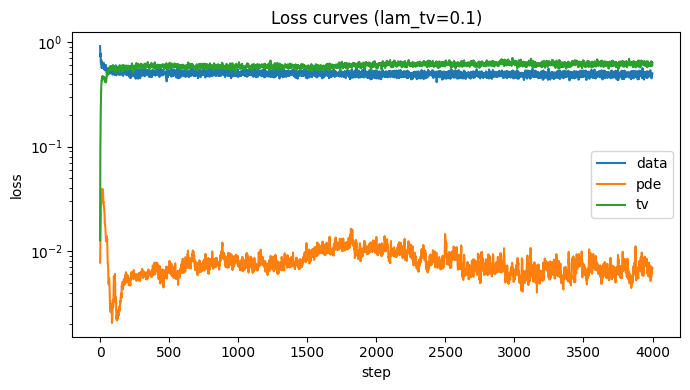

Running lambda_tv = 0.5
[lam_tv=0.5] step 0 data=9.140940e-01 pde=7.762921e-03 tv=1.267108e-02
[lam_tv=0.5] step 1000 data=4.640501e-01 pde=6.654327e-03 tv=5.463530e-01
[lam_tv=0.5] step 2000 data=4.899049e-01 pde=1.238391e-02 tv=5.206679e-01
[lam_tv=0.5] step 3000 data=5.259269e-01 pde=7.807778e-03 tv=5.565408e-01
[lam_tv= 0.5 ] effective quadratic matrix (symnet):
tensor([[-0.1563, -0.5298, -0.0243],
        [-0.5298,  0.0233, -0.0143],
        [-0.0243, -0.0143, -0.0012]])
[lam_tv= 0.5 ] readout.weight:
Parameter containing:
tensor([[-0.0618,  0.0147,  0.0025,  0.5949]], requires_grad=True)
max_abs_diff = 0.206172


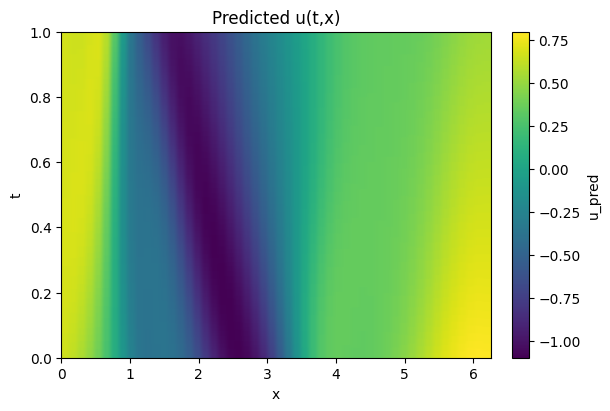

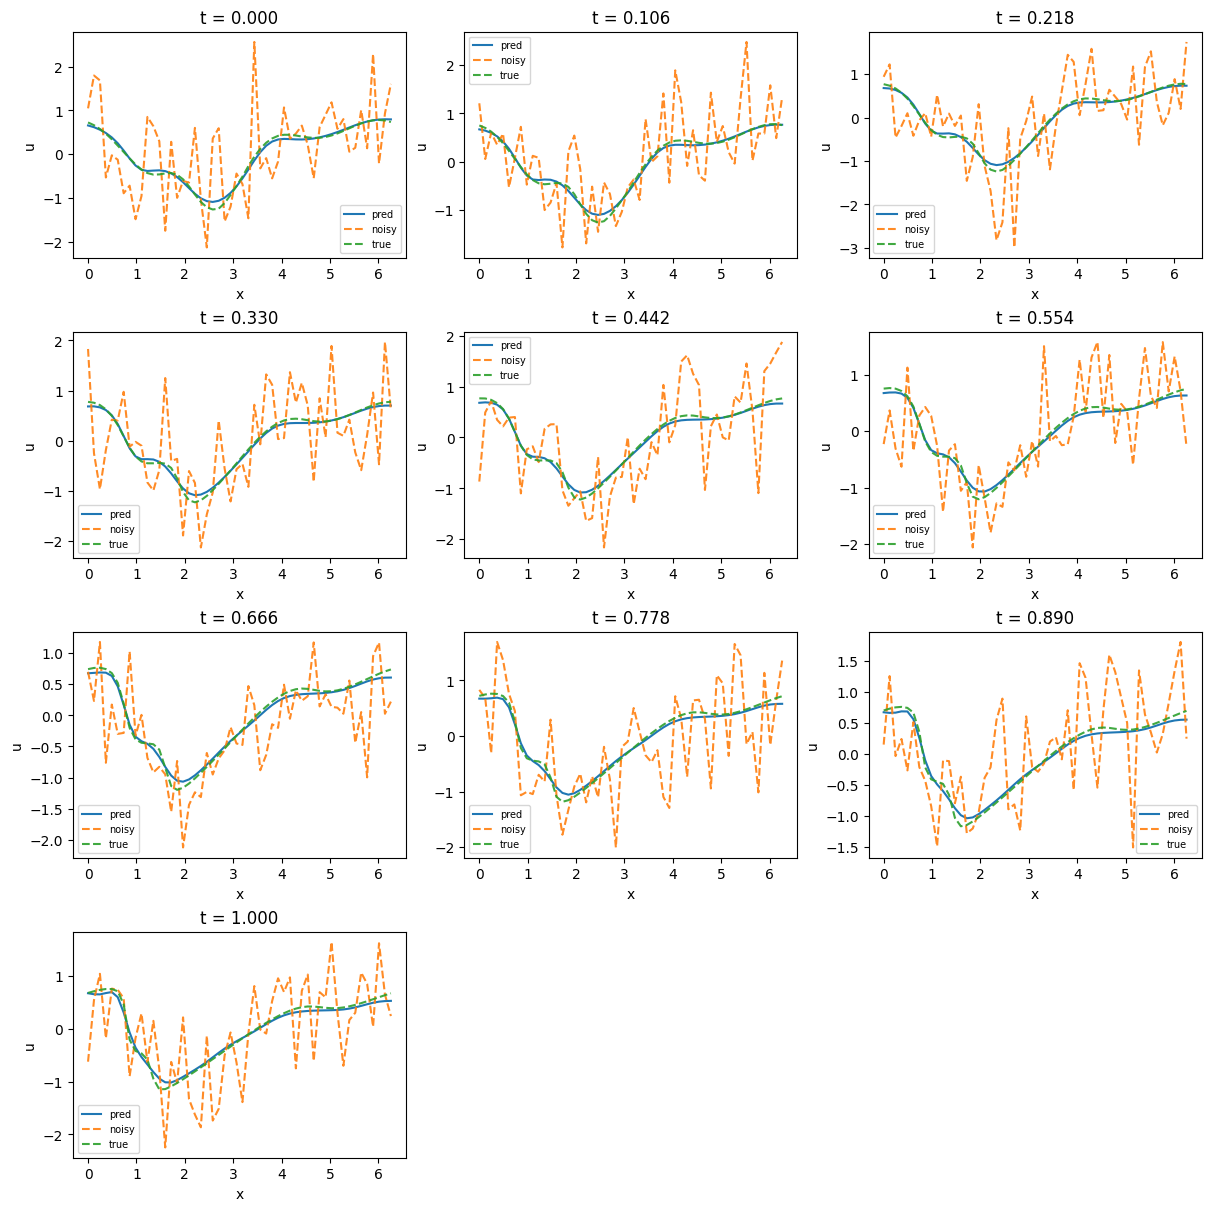

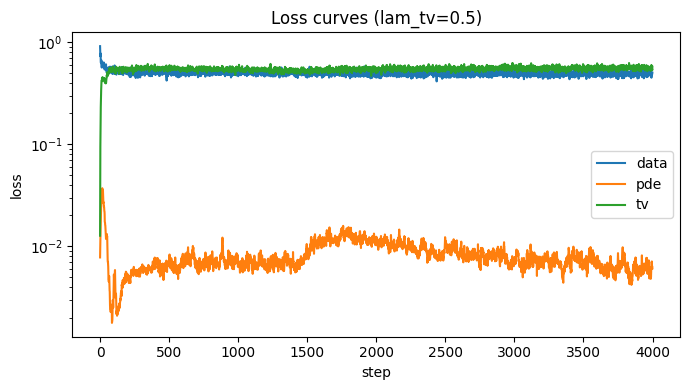

Running lambda_tv = 1
[lam_tv=1] step 0 data=9.140940e-01 pde=7.762921e-03 tv=1.267108e-02
[lam_tv=1] step 1000 data=4.655956e-01 pde=5.933899e-03 tv=4.963545e-01
[lam_tv=1] step 2000 data=4.926888e-01 pde=1.260361e-02 tv=4.752610e-01
[lam_tv=1] step 3000 data=5.309580e-01 pde=8.672951e-03 tv=5.048690e-01
[lam_tv= 1 ] effective quadratic matrix (symnet):
tensor([[-0.1669, -0.5436, -0.0295],
        [-0.5436,  0.0173, -0.0146],
        [-0.0295, -0.0146, -0.0015]])
[lam_tv= 1 ] readout.weight:
Parameter containing:
tensor([[-0.0543,  0.0047,  0.0010,  0.5784]], requires_grad=True)
max_abs_diff = 0.268123


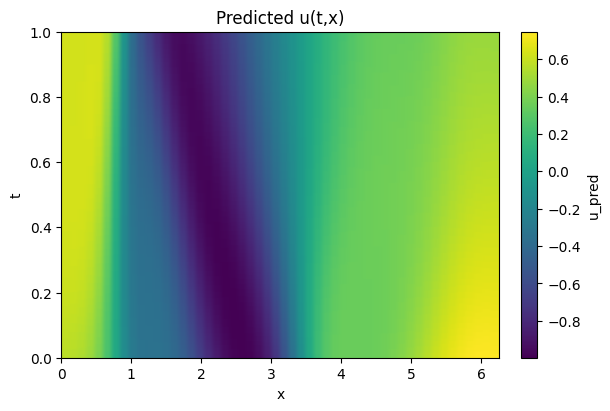

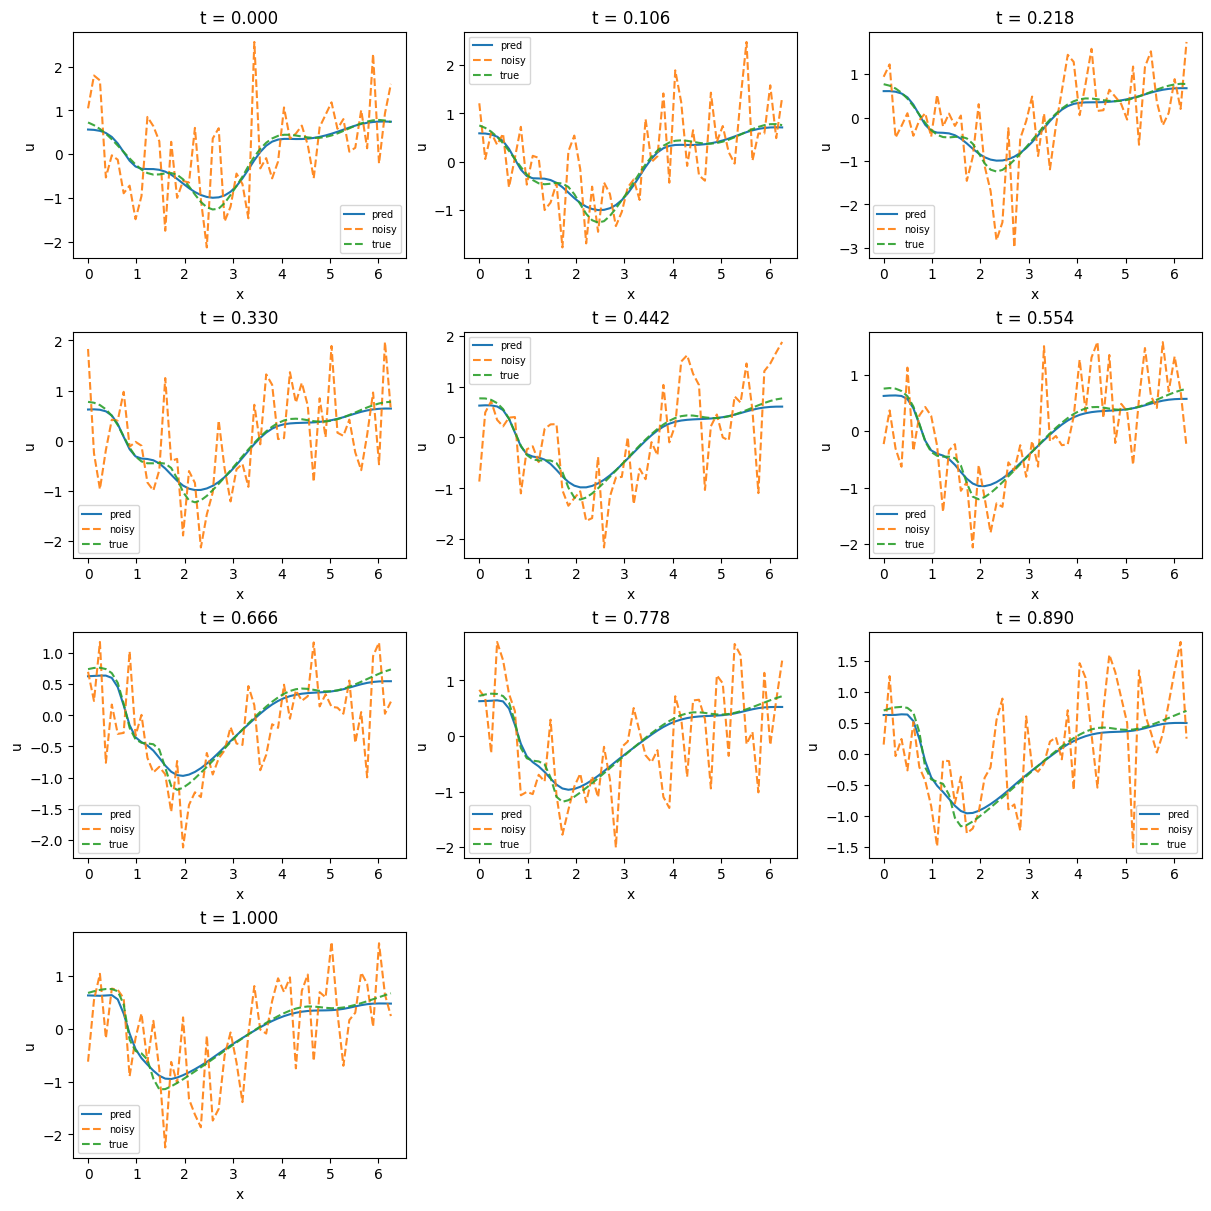

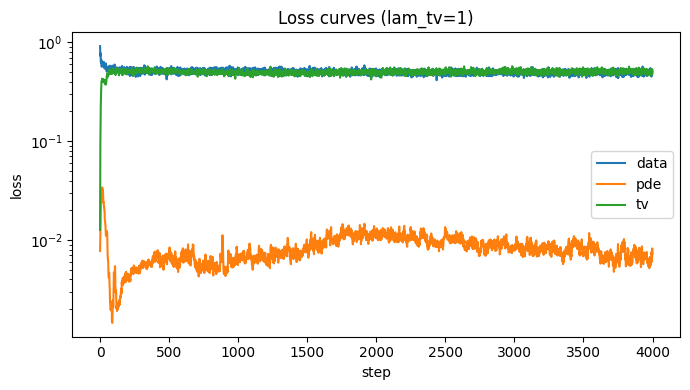

Running lambda_tv = 10.0
[lam_tv=10] step 0 data=9.140940e-01 pde=7.762921e-03 tv=1.267108e-02
[lam_tv=10] step 1000 data=6.460767e-01 pde=2.319105e-04 tv=9.787224e-02
[lam_tv=10] step 2000 data=6.706269e-01 pde=4.270381e-04 tv=1.075533e-01
[lam_tv=10] step 3000 data=7.406985e-01 pde=6.349846e-04 tv=1.123587e-01
[lam_tv= 10.0 ] effective quadratic matrix (symnet):
tensor([[-0.4184,  0.1288, -0.0038],
        [ 0.1288,  0.0740,  0.0147],
        [-0.0038,  0.0147,  0.0016]])
[lam_tv= 10.0 ] readout.weight:
Parameter containing:
tensor([[-0.3130, -0.1108, -0.0149, -0.3084]], requires_grad=True)
max_abs_diff = 0.970994


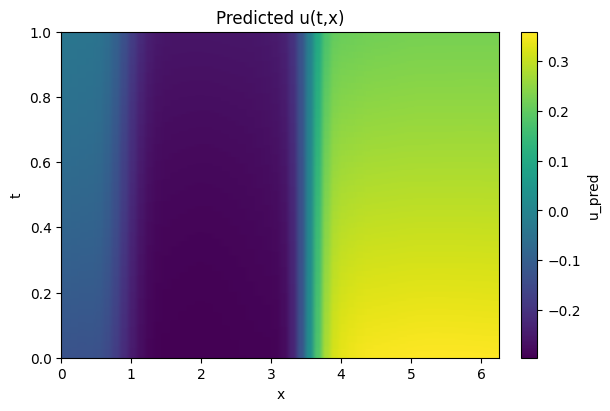

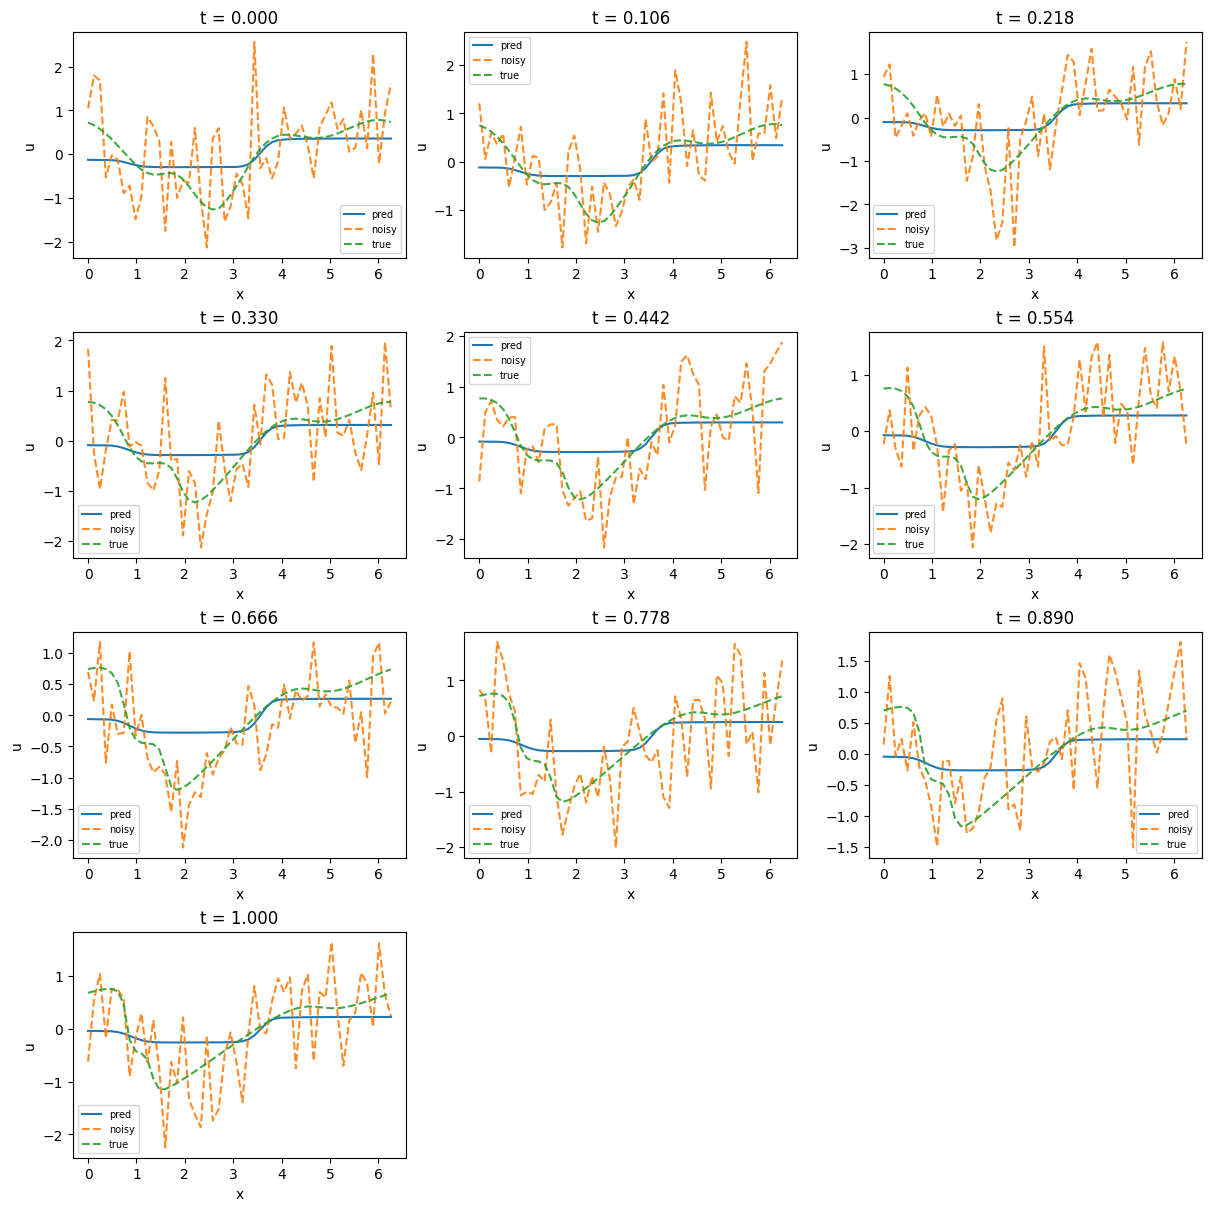

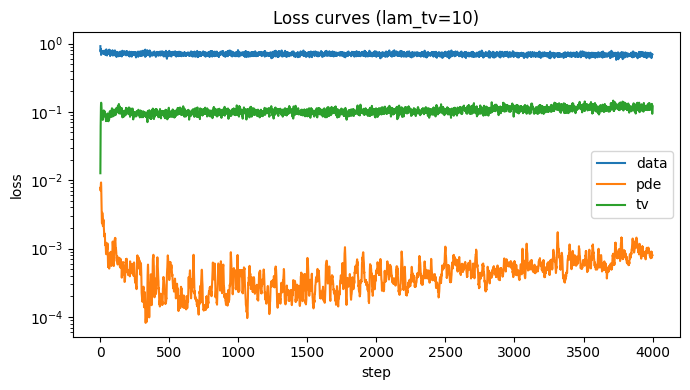

In [17]:
# Run sweeps

results = []
for lam_tv in lambda_tv_values:
    print('==============================')
    print('Running lambda_tv =', lam_tv)
    print('==============================')
    results.append(run_one(lam_tv))


In [18]:
# Compare final losses across lambda_tv

for r in results:
    print(
        f"lam_tv={r['lambda_tv']:>8g} | "
        f"final_data={r['loss_data'][-1]:.6e} "
        f"final_pde={r['loss_pde'][-1]:.6e} "
        f"final_tv={r['loss_tv'][-1]:.6e}"
    )


lam_tv=    0.01 | final_data=4.994399e-01 final_pde=6.730191e-03 final_tv=6.640052e-01
lam_tv=     0.1 | final_data=5.000750e-01 final_pde=6.890255e-03 final_tv=6.342638e-01
lam_tv=     0.5 | final_data=5.030406e-01 final_pde=6.062277e-03 final_tv=5.741525e-01
lam_tv=       1 | final_data=5.078091e-01 final_pde=7.202465e-03 final_tv=5.227994e-01
lam_tv=      10 | final_data=6.928704e-01 final_pde=8.045626e-04 final_tv=1.201067e-01
